<a href="https://colab.research.google.com/github/Kidzantso/HireGenie/blob/main/Agent5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q langgraph langchain langchain-community langchain-ollama

In [ ]:
get_ipython().system('sudo apt-get update && sudo apt-get install -y zstd')

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
import subprocess

ollama_process = subprocess.Popen(["ollama", "serve"])

In [ ]:
!ollama pull llama3

In [ ]:
from typing import TypedDict, List

class InterviewState(TypedDict):
    job_description: str
    candidate_summary: str
    candidate_projects: str

    technical_questions: List[str]
    behavioral_questions: List[str]

    final_report: str

In [ ]:
TECHNICAL_PROMPT = """
You are a senior technical interviewer.

Your task is to generate professional technical interview questions
based on:
1. The job description
2. The candidate profile
3. The candidate projects

Job Description:
{job_description}

Candidate Summary:
{candidate_summary}

Candidate Projects:
{candidate_projects}

Generate:
- 5 technical questions related to the required job skills
- 3 project-based questions related to the candidate projects
- 2 deep follow-up questions that test real understanding

Instructions:
- Ask realistic industry-level questions
- Focus on problem solving and implementation details
- If projects exist, ask about:
    - architecture
    - challenges
    - technologies used
    - model choices
    - deployment
    - optimization
    - debugging
    - real contribution of the candidate

- Avoid generic questions
- Questions should adapt to the candidate experience level
"""



BEHAVIORAL_PROMPT = """
You are an HR interviewer.

Generate 5 behavioral interview questions.

Job Description:
{job_description}

Candidate Summary:
{candidate_summary}

Focus on:
- teamwork
- leadership
- communication
- handling pressure
- conflict resolution
"""

In [ ]:
technical_prompt_template = ChatPromptTemplate.from_template(
    TECHNICAL_PROMPT
)

behavioral_prompt_template = ChatPromptTemplate.from_template(
    BEHAVIORAL_PROMPT
)

In [ ]:
technical_question_chain = (
    technical_prompt_template
    | llm
)

behavioral_question_chain = (
    behavioral_prompt_template
    | llm
)

In [ ]:
def generate_technical_questions(state):

    response = technical_question_chain.invoke({
        "job_description": state["job_description"],
        "candidate_summary": state["candidate_summary"],
        "candidate_projects": state["candidate_projects"]
    })

    return {"technical_questions": response.content.split("\n")}



def generate_behavioral_questions(state):
    response = behavioral_question_chain.invoke({
        "job_description": state["job_description"],
        "candidate_summary": state["candidate_summary"]
    })

    return {"behavioral_questions": response.content.split("\n")}


def compile_report(state):

    report = f"""
# AI Interview Question Report

==================================================

## Technical Questions

{chr(10).join(state["technical_questions"])}

==================================================

## Behavioral Questions

{chr(10).join(state["behavioral_questions"])}

==================================================
"""

    return {"final_report": report}

In [ ]:
from langgraph.graph import StateGraph, END

builder = StateGraph(InterviewState)

builder.add_node(
    "technical_questions",
    generate_technical_questions
)

builder.add_node(
    "behavioral_questions",
    generate_behavioral_questions
)

builder.add_node(
    "compile_report",
    compile_report
)

builder.set_entry_point(
    "technical_questions"
)

builder.add_edge(
    "technical_questions",
    "behavioral_questions"
)

builder.add_edge(
    "behavioral_questions",
    "compile_report"
)

builder.add_edge(
    "compile_report",
    END
)

graph = builder.compile()

In [ ]:
job_description = """
Looking for a Machine Learning Engineer with:
- Python
- NLP
- Deep Learning
- LangChain
- Vector Databases
"""
candidate_summary = """
Candidate has strong Python and TensorFlow experience.
Built NLP projects and AI chatbots.
Good teamwork and communication skills.
Limited experience with vector databases.
"""
candidate_projects = """
1. AI Chatbot using LangChain and FAISS
2. Smart Attendance System using Face Recognition
3. Resume Screening System using NLP
"""

In [ ]:
result = graph.invoke({
    "job_description": job_description,
    "candidate_summary": candidate_summary,
    "candidate_projects": candidate_projects
})

print(result["final_report"])


# AI Interview Question Report


## Technical Questions

Here are the technical interview questions, project-based questions, and deep follow-up questions:

**Technical Questions**

1. Can you explain how you would implement a language model using LangChain? What architecture would you choose, and why?

(This question tests the candidate's understanding of LangChain and their ability to design an architecture for natural language processing.)

2. How do you optimize the performance of a deep learning model when dealing with large datasets? Provide an example from your experience.

(This question evaluates the candidate's knowledge of deep learning optimization techniques and their ability to apply them in real-world scenarios.)

3. Suppose you're building a vector database from scratch. What indexing strategy would you use, and why?

(This question assesses the candidate's understanding of vector databases and their ability to design an indexing strategy for efficient querying.)

4. C

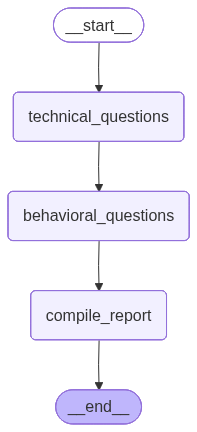

In [ ]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())